Connecting to HF2LI...
Connected to dev376

Initializing HF2LI...
  Initializing signal inputs...
    Signal inputs initialized.
  Initializing signal outputs...
    Signal outputs initialized.
  Initializing oscillators...
    Oscillators initialized.
  Initializing demodulators...
    Demodulators initialized.
  Initializing PLLs...
    PLLs initialized.
  Initializing PID controllers...
    PID controllers initialized.
  Initializing scope...
    Scope initialized.
  Initializing auxiliary outputs...
    Auxiliary outputs initialized.

Initialization complete.

Configuring output 0...
  Output configured.
Configuring input 0...
  Input configured.
Configuring input 1...
  Input configured.
Configuring demodulator 0...
  Demodulator configured.
Configuring demodulator 1...
  Demodulator configured.

Experiment folder created
Data\2026-09-03_15-44-47
Settings saved. Data\2026-09-03_15-44-47\settings.txt


Starting frequency sweep
1/1400: 500.00 Hz
141/1400: 570.05 Hz
281/1400: 640.10 

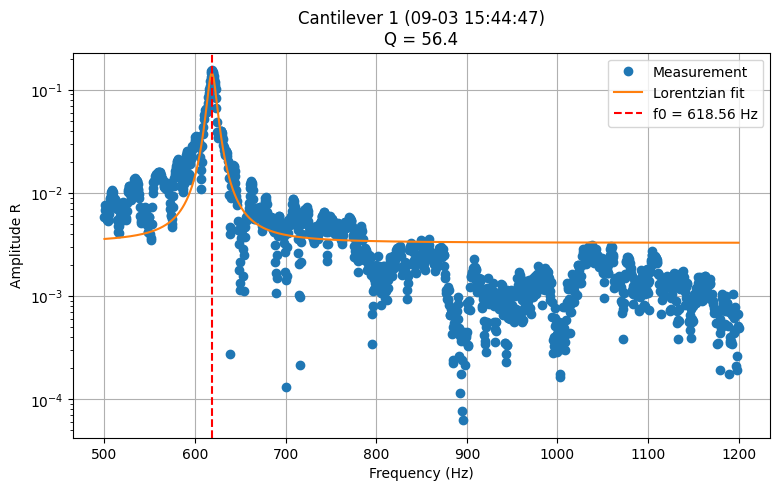

CHECKPOINT 6: PLOT 0 DONE

Starting plot demod 1


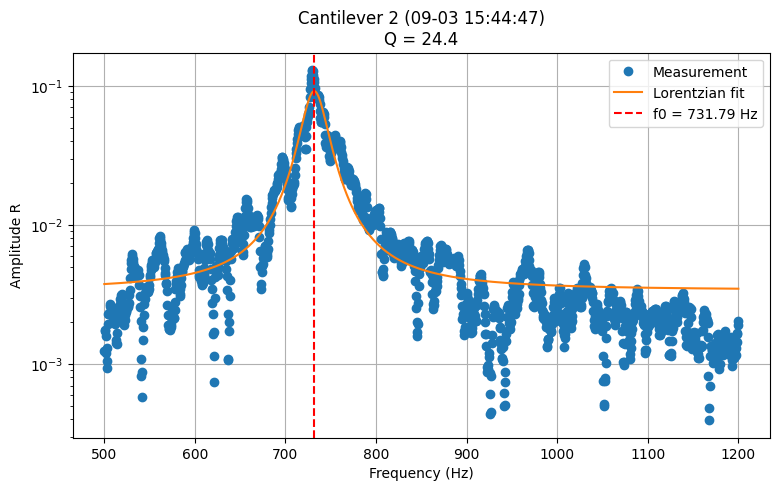

CHECKPOINT 7: PLOT 1 DONE
550.3891527455548 , 0.0042926993550993315
552.0783414124885 , 0.005206066382966552
638.3041340433581 , 0.0024534194080771017
639.0049673584128 , 0.003850827640439888
645.3154211371481 , 0.010170933153711738
660.3040419125298 , 0.010003601271302433
663.6940696143079 , 0.010306567074764307
671.4369631132666 , 0.007087037267303067
673.7220866311493 , 0.00468026487500373
675.4507479993767 , 0.005595960989952297
679.8554831569861 , 0.006006673139134476
844.5507875173624 , 0.002214139072354104
846.4683952151217 , 0.002285049632088416
906.0155722815275 , 0.001760699725766077
906.3363030915317 , 0.0018538351710061882
908.2723365510284 , 0.002281880044314991
908.3069541224271 , 0.0022709444074440572
922.1789945274845 , 0.0010495134020338638
922.7662076030025 , 0.0008832931756848827
922.8187613797922 , 0.0008794097782392348
924.0311136343934 , 0.0010776882774449358
925.225365418255 , 0.0009063820071887499
927.3283483068545 , 0.0008486048628560383
940.6072483753512 , 0.0

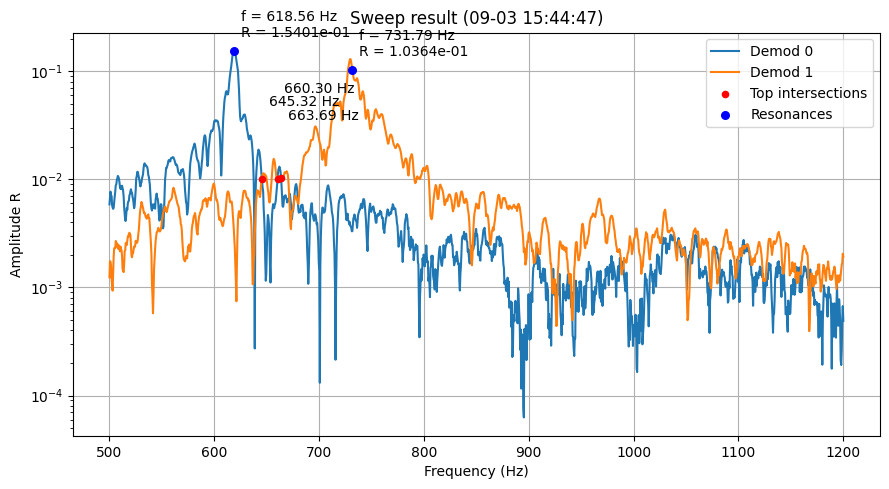

CHECKPOINT 8: SWEEP PLOT DONE.

Saving fit results

Fit saved:
Data\2026-09-03_15-44-47\fit_demod0.json
CHECKPOINT 8: FIT 0 SAVED

Fit saved:
Data\2026-09-03_15-44-47\fit_demod1.json
CHECKPOINT 9: FIT 1 SAVED. --  09-03 15:44:47


In [2]:
import os # enable the file system operation //12AUG YZ
# import json # not necesssary to import json here since the dataio.py imports it //18AUG YZ
from datetime import datetime # added for enabling timestamp in the plot title //07AUG YZ //12AUG YZ

from instrument.hf2li import HF2LI
from instrument import config 

from measurements.sweeper import FrequencySweeper
from measurements.experiment import ExperimentRunner

from utils.dataio import save_sweep_to_folder

from analysis.resonance import fit_resonance

# Create HF2LI driver, no communication to or control over the instrument yet
lockin = HF2LI(
    device_id=config.DEVICE_ID,
    host=config.SERVER_HOST,
    hf2=config.HF2
)

# connect to instrument.
lockin.connect()

# Initialize the instrument to a known safe state, and every experiment should start from this state.
# - outputs disabled
# - demodulators disabled
# - oscillators reset
# - feedback systems disabled
lockin.initialize()

# Configure experiment

# Signal output
lockin.configure_output(
    channel=config.OUTPUT_CHANNEL,
    amplitude=config.AMPLITUDE,
    offset=config.OFFSET
)

# Signal inputs
lockin.configure_input(
    channel=0,
    input_range=config.INPUT_RANGE_1
)

lockin.configure_input(
    channel=1,
    input_range=config.INPUT_RANGE_2
)

# Demodulators
lockin.configure_demod(
    demod=config.DEMOD_1,
    adc=config.ADC_1,
    oscillator=config.OSCILLATOR_1,
    rate=config.DEMOD_RATE_1
)


lockin.configure_demod(
    demod=config.DEMOD_2,
    adc=config.ADC_2,
    oscillator=config.OSCILLATOR_2,
    rate=config.DEMOD_RATE_2
)
# Create experiment folder: settings.txt sweep.npz fit results

experiment_angle = float(
    input(
        "Experimental angle (deg): "
    )
)
# ask for input the experimental angle in degrees for sweeping  // 13AUG YZ

metadata = {

    "device": config.DEVICE_ID,

    "experiment":
        "Two cantilever resonance measurement",

    "experiment_angle":
        experiment_angle

}


experiment = ExperimentRunner(
    recorder=None,
    settings=config.settings,
    metadata=metadata
)

# =========================================================
# Frequency sweep
# The oscillator frequency is swept.
# Both demodulators are recorded.
# =========================================================

timestamp = datetime.now().strftime("%m-%d %H:%M:%S") # implemenet the timestamp in the plot title //07AUG YZ // move timestamp to the beginning of sweep 12AUG YZ

sweeper = FrequencySweeper(
    lockin
)

data = sweeper.sweep(
    start_frequency=config.F_START,
    stop_frequency=config.F_STOP,
    points=config.POINTS,
    demods=(0,1),
    live_plot=False # change to false to disable live plotting //10AUG YZ
)

lockin.disable_excitation()

print()
print("Sweep finished.")
print(data.keys())
print()


# Save sweep. The raw sweep is stored inside the experiment folder.


sweep_file = save_sweep_to_folder(
    data,
    experiment.run_folder
)

print("Experiment folder:")
print(experiment.run_folder)

print("sweepfile")
print(sweep_file)


# Load saved sweep data

import numpy as np

print()
print("CHECKPOINT 1: Loading sweep")
loaded = np.load(
    sweep_file,
    allow_pickle=True
)

print("Loaded file:")
print(sweep_file)

print()
print("Available channels:")
print(loaded.files)

# Convert numpy archive into dictionary


data_loaded = {
    key: loaded[key]
    for key in loaded.files
}

print()
print("CHECKPOINT 2: Sweep converted to dictionary")

# Extract frequency and amplitudes Demod 0 -> first cantilever Demod 1 -> second cantilever


from analysis.parser import (
    get_frequency,
    get_channel
)

frequency = get_frequency(data_loaded)

amplitude_0 = get_channel(
    data_loaded,
    demod=0,
    quantity="r"
)

amplitude_1 = get_channel(
    data_loaded,
    demod=1,
    quantity="r"
)

print()
print("CHECKPOINT 3: Channels extracted")
print(
    "Frequency points:",
    len(frequency)
)
print(
    "Demod 0:",
    len(amplitude_0)
)
print(
    "Demod 1:",
    len(amplitude_1)
)

# Resonance fitting

from analysis.resonance import fit_resonance

print()
# cantilever 1/channel 1 resonance fit
print("Starting fit demod 0")
fit_0 = fit_resonance(
    frequency,
    amplitude_0
)# resonance frequency and amplitude
print()
print("Demod 0")
print(fit_0)
print("CHECKPOINT 4: FIT 0 DONE")

# fit_0 = fit_resonance get a output with structure as: //13AUG YZ
    # fit_0["f0"]          # resonance frequency
    # fit_0["gamma"]       # linewidth
    # fit_0["Q"]           # quality factor
    # fit_0["parameters"]  # fitting parameters
    # fit_0["covariance"]  # fitting uncertainty information
# there is no amplitude included in it //13AUG YZ


print()
# cantilever 2/channel 2 resonance fit
print("Starting fit demod 1")
fit_1 = fit_resonance(
    frequency,
    amplitude_1
)# resonance frequency and amplitude
print()
print("Demod 1")
print(fit_1)
print("CHECKPOINT 5: FIT 1 DONE")


# Plot resonance fits

from analysis.plotting import plot_resonance_fit
from analysis.plotting import plot_sweep

print()
print()

print(experiment.run_folder)

print("plot resonance")

plot_resonance_fit( # save the plot of the resonance has been added//15AUG YZ
    frequency,
    amplitude_0,
    fit_0,
    # title="Cantilever 1"
    save_path = os.path.join(
        experiment.run_folder,
        "resonance_cantilever_1.png"
    ),
    title=f"Cantilever 1 ({timestamp})"
)
print("CHECKPOINT 6: PLOT 0 DONE")

print()
print("Starting plot demod 1")
plot_resonance_fit(
    frequency,
    amplitude_1,
    fit_1,
    # title="Cantilever 2"
    save_path = os.path.join(
        experiment.run_folder,
        "resonance_cantilever_2.png"
    ),
    title=f"Cantilever 2 ({timestamp})"

)
print("CHECKPOINT 7: PLOT 1 DONE")

plot_sweep(
    frequency,
    amplitude_0,
    amplitude_1,
    fit_0,
    fit_1,
    timestamp=timestamp,
    save_path=os.path.join(
        experiment.run_folder,
        "sweep.png"
    )
)


print("CHECKPOINT 8: SWEEP PLOT DONE.")
from utils.dataio import save_fit

print()

print("Saving fit results")

save_fit(
    fit_0,
    experiment.run_folder,
    filename="fit_demod0.json"
)

print("CHECKPOINT 8: FIT 0 SAVED")

save_fit(
    fit_1,
    experiment.run_folder,
    filename="fit_demod1.json"
)

print("CHECKPOINT 9: FIT 1 SAVED. -- ", timestamp)


In [3]:
import os

while True: # initial input for the experiment frequency //15AUG YZ
# input the frequency in Hz//22AUG YZ
    f0_input = input(
        "Experiment frequency, q = quit: "
    ).strip()

    if f0_input.lower() == "q":
        print("Experiment finished.")
        raise SystemExit

    try:
        f0 = int(f0_input) # only accept an integer for input//15AUG YZ
        break

    except ValueError:
        print("Invalid input. Please enter an integer or q.")

while True:  # input amplitude in V //22AUG YZ
    amplitude_input = input(
        "Experiment amplitude (V), q = quit: "
    ).strip()

    if amplitude_input.lower() == "q":
        print("Experiment finished.")
        raise SystemExit

    try:
        amplitude_v = float(amplitude_input)
        break

    except ValueError:
        print("Invalid input. Please enter a number or q.")


frequency_file = os.path.join( #
    experiment.run_folder,
    f"CAL-{f0}_Hz.txt" # entered frequency will be the filename //15AUG YZ
)

while True:

    distance_input = input(
        "Distance, q = quit: "
    ).strip()

    if distance_input.lower() == "q":
        print("Experiment finished.")
        raise SystemExit

    try:
        distance = float(distance_input)
        break

    except ValueError:
        print("Invalid input. Please enter a number or q.")

with open(frequency_file, "w") as file: 
    file.write(f"{f0} Hz\n") # write the frequency value into file created //22AUG YZ
    file.write(f"{distance} cm\n") # write the distance value into file created //15AUG YZ
    file.write(f"{amplitude_v} v\n")# write the amplitude value into file created //22AUG YZ

lockin.set_frequency(f0)

# manual setting input of amplitude //22AUG YZ
lockin.configure_output(
    channel=config.OUTPUT_CHANNEL,
    amplitude=amplitude_v,
    offset=config.OFFSET
)

lockin.disable_excitation()

print("CHECKPOINT 10: FREQ and AMP SET")
#prepare for the interactive experiment

from measurements.recorder import HF2LIRecorder

print()
print("Creating recorder")

recorder = HF2LIRecorder(
    lockin,
    demods=(0,1)
)

print("CHECKPOINT 11: RECORDER CREATED")

# Attach recorder to existing experiment

experiment.recorder = recorder
print("CHECKPOINT 12: RECORDER ATTACHED")

#experiment starts

print()
print("STARTING INTERACTIVE EXPERIMENT")

experiment.run(
    duration=2.0
)

Configuring output 0...
  Output configured.
Excitation disabled
CHECKPOINT 10: FREQ and AMP SET

Creating recorder
CHECKPOINT 11: RECORDER CREATED
CHECKPOINT 12: RECORDER ATTACHED

STARTING INTERACTIVE EXPERIMENT
Excitation disabled

--------------------------------
Measurement 1

Recording...
Starting measurement
Excitation enabled
Streaming: ['/dev376/demods/0/sample', '/dev376/demods/1/sample']
Demod 0 points: 1805
Demod 1 points: 1796
Synchronizing to 1796 points
Points recorded: 1796
Excitation disabled
Excitation disabled
Recording finished.
DEBUG experiment_angle = 0.0
Saved: Data\2026-09-03_15-44-47\001_angle_0.npy
Excitation disabled

--------------------------------
Measurement 2

Recording...
Starting measurement
Excitation enabled
Streaming: ['/dev376/demods/0/sample', '/dev376/demods/1/sample']
Demod 0 points: 1800
Demod 1 points: 1791
Synchronizing to 1791 points
Points recorded: 1791
Excitation disabled
Excitation disabled
Recording finished.
DEBUG experiment_angle = 10

Reading:  Data\2026-09-03_15-44-47
001_angle_0.npy  - loaded- 
002_angle_10.npy  - loaded- 
003_angle_20.npy  - loaded- 
004_angle_30.npy  - loaded- 
005_angle_40.npy  - loaded- 
006_angle_50.npy  - loaded- 
007_angle_60.npy  - loaded- 
008_angle_70.npy  - loaded- 
009_angle_80.npy  - loaded- 
010_angle_90.npy  - loaded- 
011_angle_100.npy  - loaded- 
012_angle_110.npy  - loaded- 
013_angle_120.npy  - loaded- 
014_angle_130.npy  - loaded- 
015_angle_140.npy  - loaded- 
016_angle_150.npy  - loaded- 
017_angle_160.npy  - loaded- 
018_angle_170.npy  - loaded- 
019_angle_180.npy  - loaded- 
020_angle_190.npy  - loaded- 
021_angle_200.npy  - loaded- 
022_angle_210.npy  - loaded- 
023_angle_220.npy  - loaded- 
024_angle_230.npy  - loaded- 
025_angle_240.npy  - loaded- 
026_angle_250.npy  - loaded- 
027_angle_260.npy  - loaded- 
028_angle_270.npy  - loaded- 
029_angle_280.npy  - loaded- 
030_angle_290.npy  - loaded- 
031_angle_300.npy  - loaded- 
032_angle_310.npy  - loaded- 
033_angle_320.np

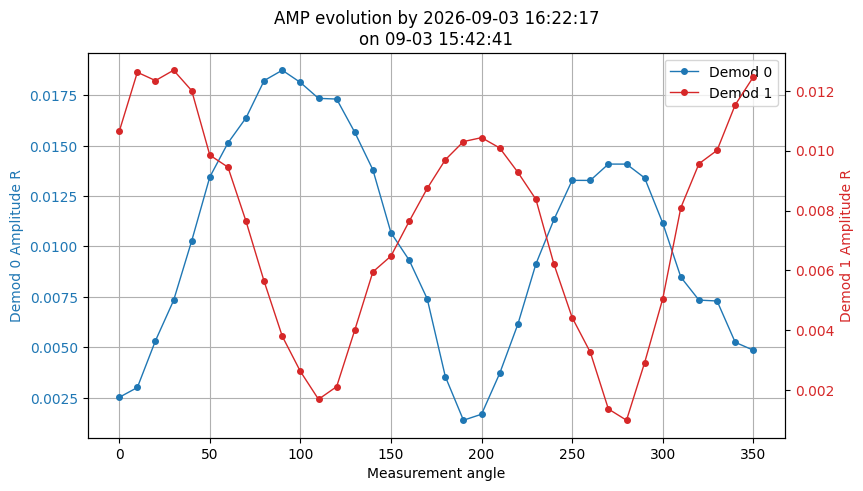

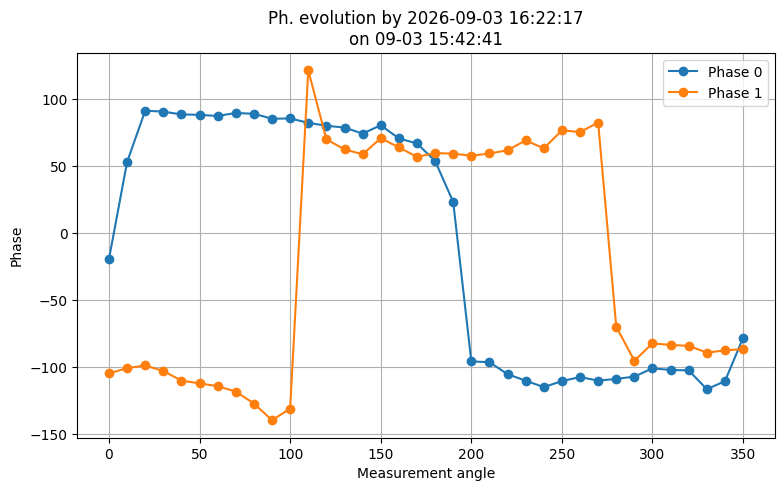

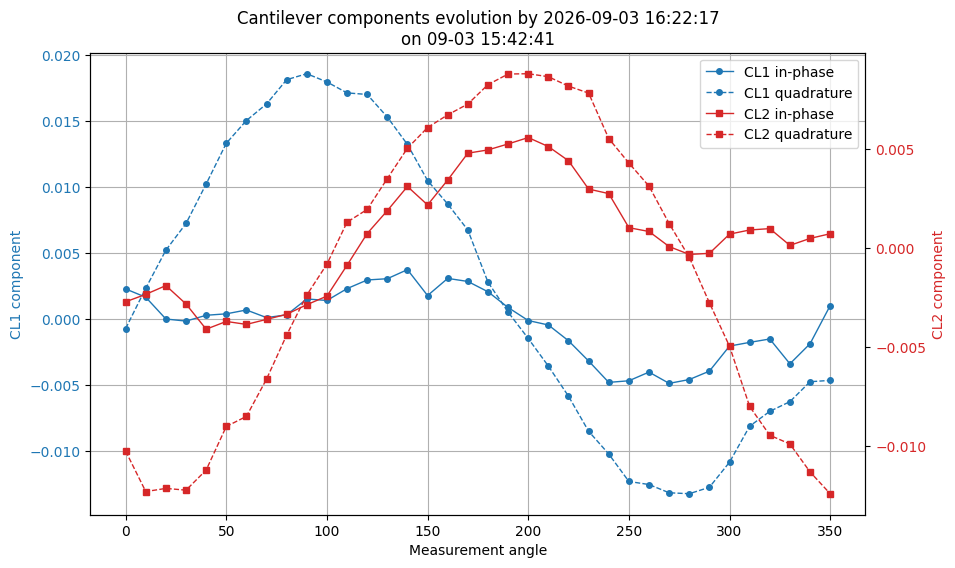

summary and its plottings are done

Calibration built from CSV 2026-09-03T16:22:26.405262
Source: Data\2026-09-03_15-44-47\summary.csv
Number of angles: 36
{'angles': array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.,
       110., 120., 130., 140., 150., 160., 170., 180., 190., 200., 210.,
       220., 230., 240., 250., 260., 270., 280., 290., 300., 310., 320.,
       330., 340., 350.]), 'Cantilever 1': array([ 2.27588069e-03-0.00073047j,  1.64785637e-03+0.00233468j,
       -4.57920442e-06+0.0052177j , -1.61971768e-04+0.00724065j,
        2.78806833e-04+0.0102369j ,  3.88541050e-04+0.01332497j,
        6.80156282e-04+0.01505012j,  1.02711595e-04+0.01630831j,
        3.10658754e-04+0.01814841j,  1.51615961e-03+0.01860004j,
        1.40191774e-03+0.01797541j,  2.30081308e-03+0.01714576j,
        2.95621567e-03+0.01702729j,  3.05221145e-03+0.01531221j,
        3.74079705e-03+0.01323298j,  1.77440700e-03+0.0104948j ,
        3.07528073e-03+0.00871649j,  2.84481731e-03

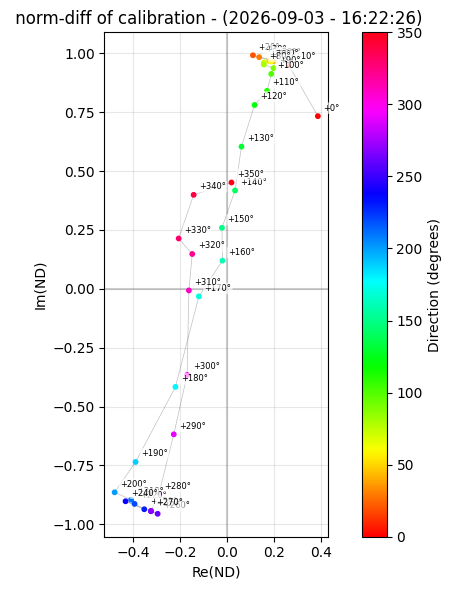

calibration by norm_diff plotted and saved 09-03 15:42:41
71 67 77 89
=-=-=-=-=-=


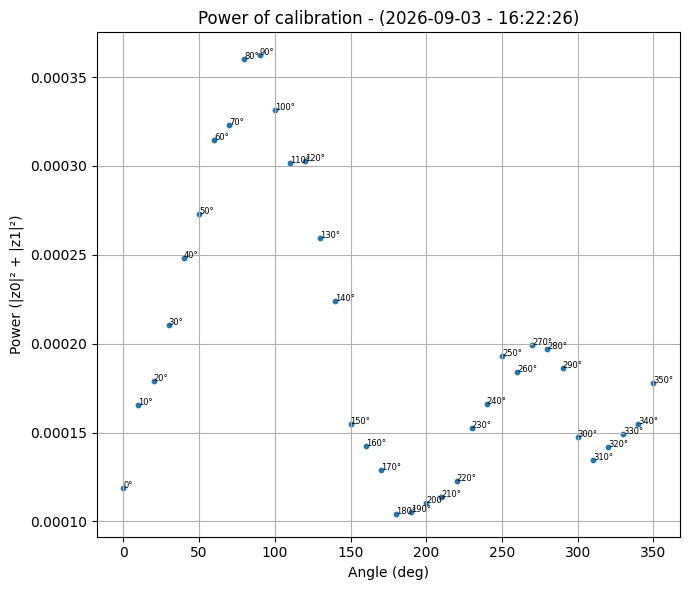

Calibration power plotted and saved 09-03 15:42:41
calibration and plots are done
09-03 16:22:26


In [4]:
# new cell for loading calibration files to generate summary //17AUG YZ
import numpy as np
import json

import os
from datetime import datetime
from analysis.measurement_reader import (
    load_measurements,
    summarize_measurements,
    fit_load
)
from utils.dataio import save_summary # file operations are in dataio.py 

from analysis.calibration import save_calibration
from analysis.calibration import build_calibration_from_csv
from analysis.calibration import load_calibration
from analysis.plotting import plot_calibration_norm_diff #19AUG YZ
from analysis.plotting import plot_calibration_power #30AUG YZ

timestamp = datetime.now().strftime("%m-%d %H:%M:%S")
experiment_folder = r"Data\copy\16AUG\2026-08-16_13-24-34" # path for calibration, manual input required
#dest_folder = experiment_folder
dest_folder = experiment.run_folder

print("Reading: ", dest_folder)

measurements = load_measurements(dest_folder)

summary = summarize_measurements(measurements)

save_summary(summary,dest_folder)

from analysis.plotting import (
    plot_amplitude_summary,
    plot_phase_summary,
    plot_components_summary    
)

plot_amplitude_summary(
    summary,
    save_path=os.path.join(dest_folder,"amplitude_summary.png")
)

plot_phase_summary(
    summary,
    save_path=os.path.join(dest_folder,"phase_summary.png")
)

plot_components_summary(summary, save_path=dest_folder) # under the file name of CL1_CL2_components_EVL

print("summary and its plottings are done")

#experiment_folder = r"data\2026-08-31_13-01-56" # input the experiement folder //13AUG YZ
#dest_folder = experiment_folder
#dest_folder =experiment.run_folder


# build the calibration file //13AUG YZ
calibration_REC = build_calibration_from_csv(dest_folder)

save_calibration(calibration_REC,
    dest_folder + r"\calibration_from_summary.npy")

calibration = load_calibration(
    dest_folder + r"\calibration_from_summary.npy")



plot_calibration_norm_diff(calibration,
    save_path=os.path.join(dest_folder,"mean_norm_diff.png"))#plot normalized difference (mean(z0)-mean(z1))/(abs(mean(z0))+abs(mean(z1))) //19AUG YZ

plot_calibration_power(calibration,
    save_path=os.path.join(dest_folder,"mean_power.png"))# plot power of cantilevers

print("calibration and plots are done")
print(timestamp)

In [ ]:
# experiement is continued with the calibration steps from previous cells //04SEP YZ
experiment.loc_run(
    duration=2.0
)
print(experiment.run_folder)

Excitation disabled


Recording...
Starting measurement
Excitation enabled
Streaming: ['/dev376/demods/0/sample', '/dev376/demods/1/sample']
Demod 0 points: 1804
Demod 1 points: 1787
Synchronizing to 1787 points
Points recorded: 1787
Excitation disabled
Excitation disabled
Recording finished, 280.0° - 100.0cm - EXT.
Saved: Data\2026-09-03_15-44-47\AUE280_100_EXT.npy
Data\2026-09-03_15-44-47


In [1]:
# arbitrary point location for the estimation, independent from the calibration, will excute a measurement and save data into a given folder //04SEP YZ

# define the detination folder for the measurement, manual input required //04SEP YZ

from measurements.experiment import arb_run

experiment_folder = r"data\2026-09-03_15-44-47"
dest_folder = experiment_folder
# dest_folder = experiment.run_folder

arb_run(
    recorder=experiment.recorder,
    dest_folder=dest_folder,
    duration=2.0
)

NameError: name 'experiment' is not defined

['Data\\2026-09-03_15-44-47\\AUE280_100_EXT.npy']
point_loc  {'angle': array([280.]), 'Cantilever 1': array([-0.01553197-0.00664865j]), 'Cantilever 2': array([-0.00082326-0.00116563j]), 'ratio_points': array([10.08453768-6.20245178j]), 'diff_points': array([-0.01470871-0.00548302j]), 'ratio_mean_mag': array([11.7035801]), 'r_0': array([0.01690258]), 'r_1': array([0.00144422]), 'phase_0': array([-156.80622113]), 'phase_1': array([-124.99999955]), 'norm_diff': array([-0.80278031-0.29925536j]), 'power': array([0.00028748]), 'source_files': ['AUE280_100_EXT.npy'], 'created': '2026-09-03T19:08:57.687456'}
norm_diff_point_loc -  {'norm_diff': array([-0.80278031-0.29925536j]), 'source_file': ['AUE280_100_EXT.npy']}  - MAG -  [0.85674383]
comp_point_loc -  {'z0': array([-0.01553197-0.00664865j]), 'z1': array([-0.00082326-0.00116563j]), 'power': array([0.00028748]), 'source_file': ['AUE280_100_EXT.npy']}
Angle: +110.0°, Residual: 0.000288, C: (-0.49883284438824615+0.8388741858644149j)
Angle: +2

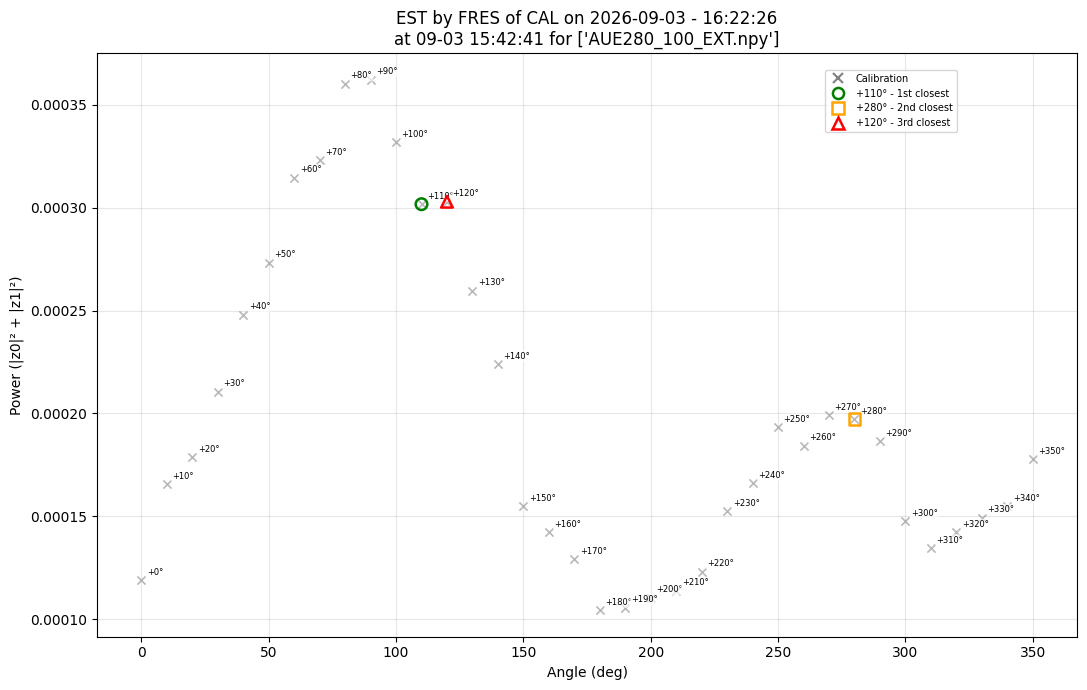

FRES estimation plotted and saved 09-03 15:42:41
AUE_FRES DONE
AUE DONE


In [123]:
from measurements.experiment import con_AUE # convert an AUE file to a variant//20AUG YZ
from measurements.experiment import est_LDND # estimation by LDND //21AUG YZ
from measurements.experiment import est_FRES # estimation by FRES //30AUG YZ
# from measurements.experiment import est_DIFF # estimation by DIFF //03SEP YZ

from analysis.plotting import plot_loc_est # plot estimation //21AUG YZ
from analysis.plotting import plot_pwr_est

import os

import glob

experiment_folder = r"Data\2026-09-02_13-15-57"
dest_folder = experiment.run_folder
#dest_folder = experiment_folder

AUE_files = glob.glob(os.path.join(dest_folder, "*AUE*.npy"))
print(AUE_files)
for AUE_file in AUE_files:
    # convert the measurement file of the interested point to an dictionary variant //21AUG YZ
    point_loc = con_AUE(AUE_file)    
    print("point_loc ", point_loc)

    norm_diff_point_loc = {
        "norm_diff": point_loc["norm_diff"],
        "source_file": point_loc["source_files"]
    } # take out the value of normalized difference from the above variant //20AUU YZ
    print("norm_diff_point_loc - ", norm_diff_point_loc," - MAG - ", abs(norm_diff_point_loc["norm_diff"]))

    comp_point_loc = {
        "z0": point_loc["Cantilever 1"],
        "z1": point_loc["Cantilever 2"],
        "power": point_loc["power"],
        "source_file": point_loc["source_files"]
    } # take out the value of cantilvers response in complex from the above variant, will be used in full residual estimation//28AUG YZ
    print("comp_point_loc - ", comp_point_loc)

   
    # AUE_LDND = est_LDND ( 
    #     norm_diff_point_loc, 
    #     dest_folder + r"\calibration_from_summary.npy"
    # )   
    # plot_loc_est(
    #     norm_diff_point_loc,
    #     AUE_LDND,
    #     dest_folder + r"\calibration_from_summary.npy",
    #     dest_folder + r"\LDND_" + os.path.splitext(os.path.basename(point_loc["source_files"][0]))[0] + ".png"
    # )    
    # print("AUE_LDND DONE")

    AUE_FRES = est_FRES(
        comp_point_loc,
        dest_folder + r"\calibration_from_summary.npy"
    )
    plot_pwr_est(
        comp_point_loc,
        AUE_FRES,
        dest_folder + r"\calibration_from_summary.npy",
        dest_folder + r"\FRES_" + os.path.splitext(os.path.basename(point_loc["source_files"][0]))[0] + ".png"
    )
    print("AUE_FRES DONE")

    # AUE_DIFF = est_DIFF(
    #     comp_point_loc,
    #     dest_folder + r"\calibration_from_summary.npy"
    # )
    # print("AUE_DIFF DONE")

print("AUE DONE")
# print(timestamp)    



In [27]:
# more summary plotting, begins //01SEP YZ
from analysis.plotting import (  
    plot_xcomp_summary,
    plot_ycomp_summary,
)

In [ ]:
# more calibration plotting //01SEP YZ
# from analysis.plotting import plot_calibration
# from analysis.plotting import plot_calibration_cantilevers #11AUG YZ
# from analysis.plotting import plot_calibration_diff #12AUG YZ
# from analysis.plotting import plot_calibration_rmmag
# plot_calibration(calibration,
#     save_path=os.path.join(dest_folder,"ratio_mean_cplx.png"))#plot cantilever 1 / cantilever 2

# plot_calibration_cantilevers(calibration,
#     save_path_CL1 = os.path.join(dest_folder,"mean_CL1.png"),
#     save_path_CL2 = os.path.join(dest_folder,"mean_CL2.png"))#plot cantilever characteristics from CH1 CH2 //11AUG YZ

# plot_calibration_rmmag(calibration,
#     save_path=os.path.join(dest_folder,"ratio_mean_mag.png")) #plot Mean(|z0|) / Mean(|z1|)

# plot_calibration_diff(calibration,
#     save_path=os.path.join(dest_folder,"diff_mean.png")) #plot cantilever 1 - cantilever 2

In [ ]:
#calibration section //01SEP YZ
# from datetime import datetime
# import os

# timestamp = datetime.now().strftime("%m-%d %H:%M:%S")
# from analysis.calibration import save_calibration
# from analysis.calibration import build_calibration_from_csv
# from analysis.calibration import load_calibration


# from analysis.plotting import plot_calibration_norm_diff #19AUG YZ
# from analysis.plotting import plot_calibration_power #30AUG YZ

# experiment_folder = r"data\2026-08-31_13-01-56" # input the experiement folder //13AUG YZ
# #dest_folder = experiment_folder
# dest_folder =experiment.run_folder


# # build the calibration file //13AUG YZ
# calibration_REC = build_calibration_from_csv(dest_folder)

# save_calibration(calibration_REC,
#     dest_folder + r"\calibration_from_summary.npy")

# calibration = load_calibration(
#     dest_folder + r"\calibration_from_summary.npy")



# plot_calibration_norm_diff(calibration,
#     save_path=os.path.join(dest_folder,"mean_norm_diff.png"))#plot normalized difference (mean(z0)-mean(z1))/(abs(mean(z0))+abs(mean(z1))) //19AUG YZ

# plot_calibration_power(calibration,
#     save_path=os.path.join(dest_folder,"mean_power.png"))# plot power of cantilevers

# print("calibration and plots are done")
# print(timestamp)

In [ ]:
from project_summary import summarize_project

summarize_project()

In [ ]:
from project_summary import build_project_documentation

build_project_documentation()